# An Intelligent Spam Email Detection System Using Natural Language Processing

## Install Libraries

In [4]:
!pip install pandas numpy nltk scikit-learn matplotlib seaborn wordcloud imbalanced-learn

## Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import warnings
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
warnings.filterwarnings("ignore")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
print("All libraries imported successfully.")

All libraries imported successfully.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Load Dataset

In [6]:
df = pd.read_csv("emails.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## Exploratory Data Analysis

### Dataset Overview

In [7]:
print("Dataset Information:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None

Descriptive Statistics:
              spam
count  5728.000000
mean      0.238827
std       0.426404
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000

Missing Values:
text    0
spam    0
dtype: int64


### Class Distribution

Class Distribution:
Not Spam (0): 4360
Spam (1):     1368
Total:        5728
Imbalance ratio: 3.19 :1 (Not Spam:Spam)


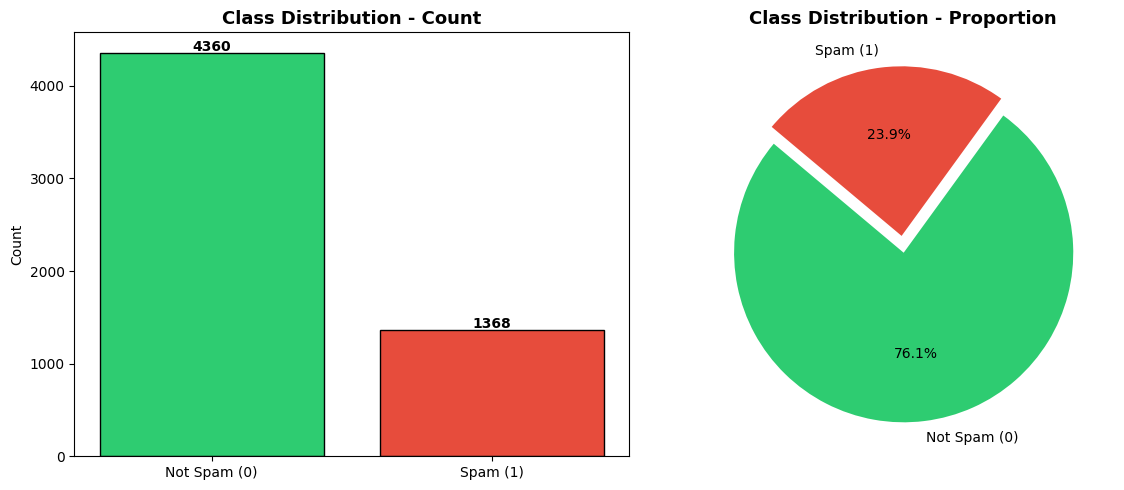

In [8]:
label_col = "spam" if "spam" in df.columns else df.columns[1]
text_col = "text" if "text" in df.columns else df.columns[0]
class_counts = df[label_col].value_counts()
print("Class Distribution:")
print("Not Spam (0):", class_counts[0])
print("Spam (1):    ", class_counts[1])
print("Total:       ", len(df))
print("Imbalance ratio:", round(class_counts[0]/class_counts[1], 2), ":1 (Not Spam:Spam)")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(["Not Spam (0)", "Spam (1)"], class_counts.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Class Distribution - Count", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")
axes[1].pie(class_counts.values, labels=["Not Spam (0)", "Spam (1)"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=140, explode=(0.05, 0.05))
axes[1].set_title("Class Distribution - Proportion", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Email Length Analysis

Email Length Statistics by Class:
     email_length                                                            \
            count     mean      std   min     25%     50%      75%      max   
spam                                                                          
0          4360.0  1631.92  1959.66  13.0  577.75  1122.0  2037.25  43952.0   
1          1368.0  1317.26  2271.37  18.0  401.50   693.5  1250.25  28432.0   

     word_count                                                     
          count    mean     std  min    25%    50%     75%     max  
spam                                                                
0        4360.0  345.80  406.19  2.0  119.0  239.0  439.25  8477.0  
1        1368.0  266.43  451.46  4.0   79.0  139.5  251.00  6129.0  


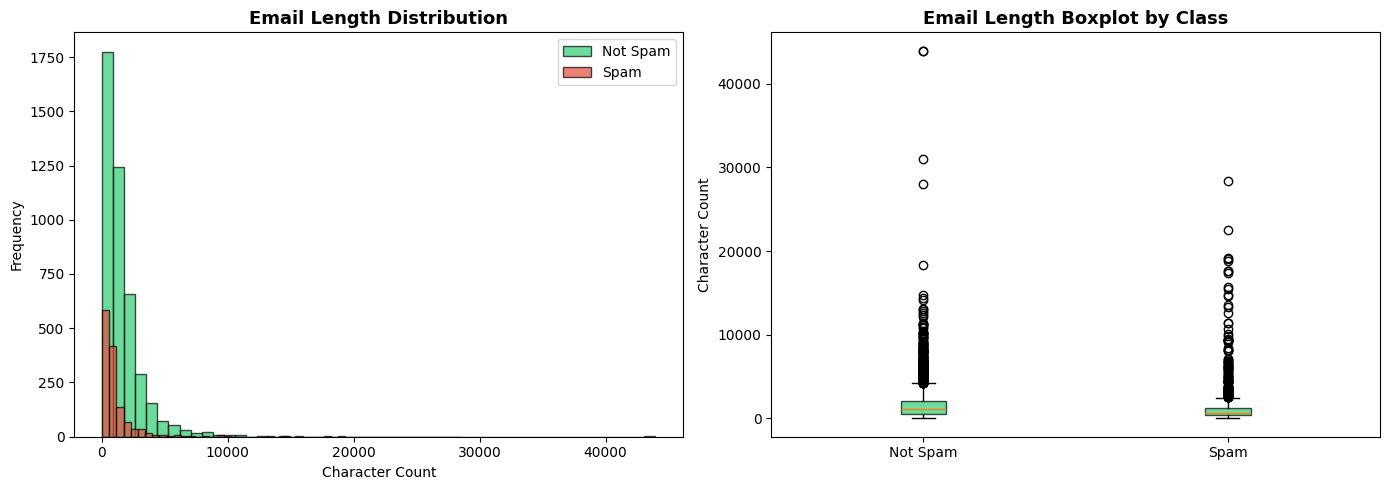

In [9]:
df["email_length"] = df[text_col].astype(str).apply(len)
df["word_count"] = df[text_col].astype(str).apply(lambda x: len(x.split()))
print("Email Length Statistics by Class:")
print(df.groupby(label_col)[["email_length", "word_count"]].describe().round(2))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
spam_lengths = df[df[label_col] == 1]["email_length"]
ham_lengths = df[df[label_col] == 0]["email_length"]
axes[0].hist(ham_lengths, bins=50, alpha=0.7, color="#2ecc71", label="Not Spam", edgecolor="black")
axes[0].hist(spam_lengths, bins=50, alpha=0.7, color="#e74c3c", label="Spam", edgecolor="black")
axes[0].set_title("Email Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[1].boxplot([ham_lengths, spam_lengths], labels=["Not Spam", "Spam"],
                patch_artist=True, boxprops=dict(facecolor="#2ecc71", alpha=0.7))
axes[1].set_title("Email Length Boxplot by Class", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Character Count")
plt.tight_layout()
plt.savefig("email_length_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Word Cloud Visualisation

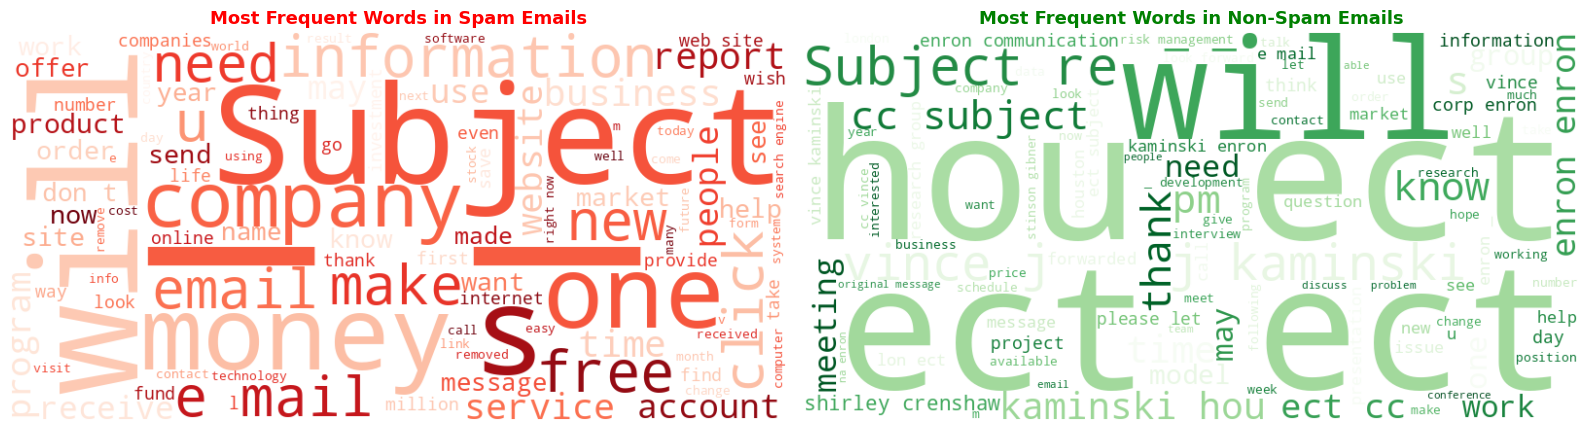

In [10]:
spam_text = " ".join(df[df[label_col] == 1][text_col].astype(str).tolist())
ham_text = " ".join(df[df[label_col] == 0][text_col].astype(str).tolist())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
wc_spam = WordCloud(width=800, height=400, background_color="white", colormap="Reds", max_words=100).generate(spam_text)
axes[0].imshow(wc_spam, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Most Frequent Words in Spam Emails", fontsize=13, fontweight="bold", color="red")
wc_ham = WordCloud(width=800, height=400, background_color="white", colormap="Greens", max_words=100).generate(ham_text)
axes[1].imshow(wc_ham, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Most Frequent Words in Non-Spam Emails", fontsize=13, fontweight="bold", color="green")
plt.tight_layout()
plt.savefig("wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

## Data Preprocessing

### Text Cleaning and NLP Pipeline

In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print("Applying preprocessing pipeline...")
df["cleaned_text"] = df[text_col].apply(preprocess_text)
print("Preprocessing complete!")
print("\nSample - Original Text:")
print(df[text_col].iloc[0][:300])
print("\nSample - Cleaned Text:")
print(df["cleaned_text"].iloc[0][:300])

Applying preprocessing pipeline...
Preprocessing complete!

Sample - Original Text:
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that h

Sample - Cleaned Text:
subject naturally irresistible corporate identity really hard recollect company market full suqgestions information isoverwhelminq good catchy logo stylish statlonery outstanding website make task much easier promise havinq ordered iogo company automaticaily become world ieader isguite ciear without


### Preprocessing Statistics

In [12]:
df["cleaned_word_count"] = df["cleaned_text"].apply(lambda x: len(x.split()))
print("Word Count Before Preprocessing:")
print(df["word_count"].describe().round(2))
print("\nWord Count After Preprocessing:")
print(df["cleaned_word_count"].describe().round(2))
reduction = ((df["word_count"].mean() - df["cleaned_word_count"].mean()) / df["word_count"].mean()) * 100
print("\nAverage word count reduction after preprocessing:", round(reduction, 2), "%")

Word Count Before Preprocessing:
count    5728.00
mean      326.85
std       418.78
min         2.00
25%       101.00
50%       210.00
75%       401.00
max      8477.00
Name: word_count, dtype: float64

Word Count After Preprocessing:
count    5728.00
mean      131.40
std       174.72
min         2.00
25%        45.00
50%        83.00
75%       156.00
max      3957.00
Name: cleaned_word_count, dtype: float64

Average word count reduction after preprocessing: 59.8 %


## Feature Extraction

### TF-IDF Vectorisation

In [13]:
X = df["cleaned_text"]
y = df[label_col]
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train_text.shape[0])
print("Testing set size: ", X_test_text.shape[0])
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training set size: 4582
Testing set size:  1146

Training class distribution:
spam
0    3488
1    1094
Name: count, dtype: int64

Testing class distribution:
spam
0    872
1    274
Name: count, dtype: int64


In [14]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)
print("TF-IDF Feature Matrix Shape (Training):", X_train.shape)
print("TF-IDF Feature Matrix Shape (Testing): ", X_test.shape)
print("Total features (vocabulary size):", len(tfidf_vectorizer.vocabulary_))

TF-IDF Feature Matrix Shape (Training): (4582, 10000)
TF-IDF Feature Matrix Shape (Testing):  (1146, 10000)
Total features (vocabulary size): 10000


### Top TF-IDF Features by Class

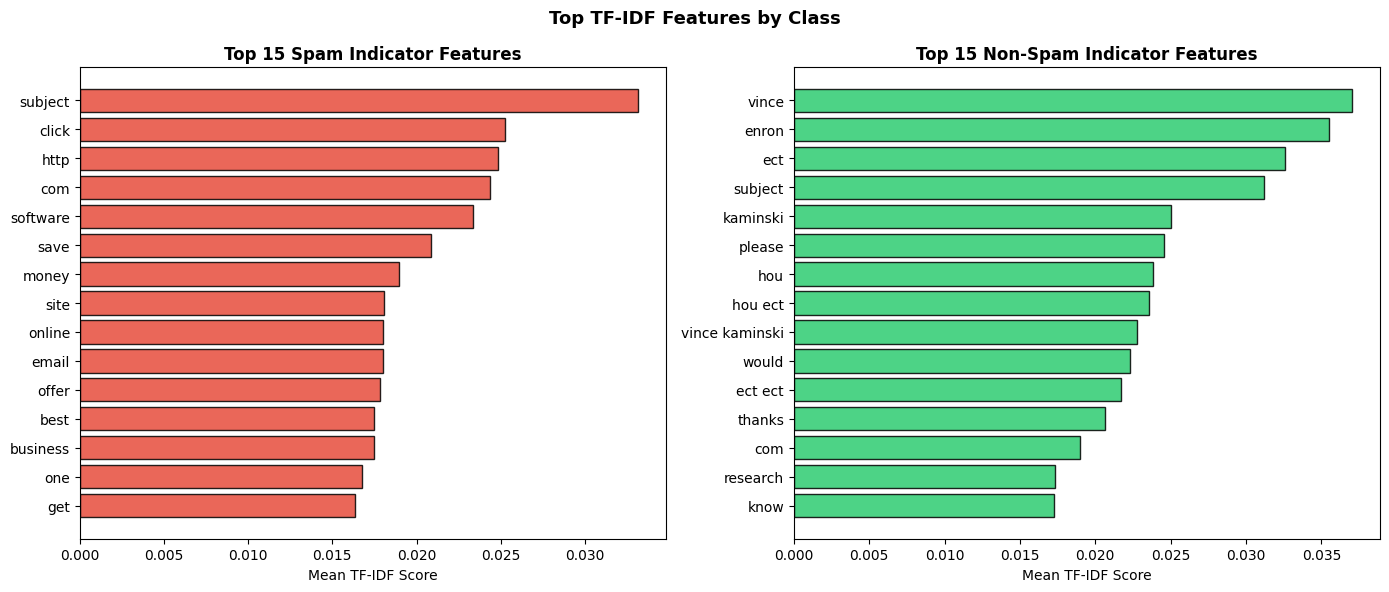

In [15]:
feature_names = tfidf_vectorizer.get_feature_names_out()
X_train_arr = X_train.toarray()
y_train_arr = np.array(y_train)
spam_mean = X_train_arr[y_train_arr == 1].mean(axis=0)
ham_mean  = X_train_arr[y_train_arr == 0].mean(axis=0)
top_spam_idx = spam_mean.argsort()[-15:][::-1]
top_ham_idx  = ham_mean.argsort()[-15:][::-1]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(range(15), spam_mean[top_spam_idx], color="#e74c3c", edgecolor="black", alpha=0.85)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(feature_names[top_spam_idx])
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean TF-IDF Score")
axes[0].set_title("Top 15 Spam Indicator Features", fontsize=12, fontweight="bold")
axes[1].barh(range(15), ham_mean[top_ham_idx], color="#2ecc71", edgecolor="black", alpha=0.85)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feature_names[top_ham_idx])
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean TF-IDF Score")
axes[1].set_title("Top 15 Non-Spam Indicator Features", fontsize=12, fontweight="bold")
plt.suptitle("Top TF-IDF Features by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("top_tfidf_features.png", dpi=150, bbox_inches="tight")
plt.show()

## Class Imbalance Handling

### SMOTE Oversampling

Class distribution BEFORE SMOTE:
spam
0    3488
1    1094
Name: count, dtype: int64

Class distribution AFTER SMOTE:
spam
0    3488
1    3488
Name: count, dtype: int64


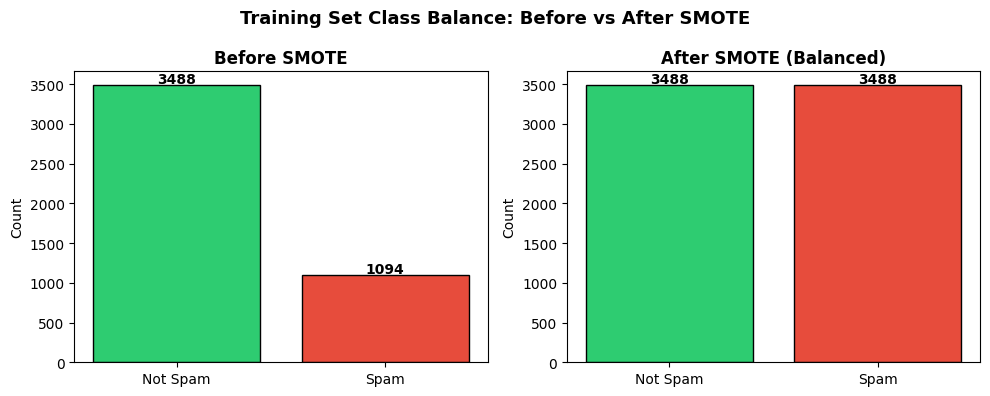

In [16]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("Class distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_balanced).value_counts().sort_index()
axes[0].bar(["Not Spam", "Spam"], before.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Before SMOTE", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(before.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")
axes[1].bar(["Not Spam", "Spam"], after.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[1].set_title("After SMOTE (Balanced)", fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate(after.values):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.suptitle("Training Set Class Balance: Before vs After SMOTE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("smote_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Implementation and Training

### Define Models

In [17]:
models = {
    "Naive Bayes":            MultinomialNB(alpha=0.1),
    "Logistic Regression":    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Support Vector Machine": LinearSVC(C=1.0, max_iter=2000, random_state=42),
    "Random Forest":          RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}
print("Models defined:")
for name in models:
    print(" -", name)

Models defined:
 - Naive Bayes
 - Logistic Regression
 - Support Vector Machine
 - Random Forest


### Train and Evaluate Models

In [18]:
results = {}
trained_models = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for model_name, model in models.items():
    print("Training:", model_name)
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=skf, scoring="f1")
    results[model_name] = {
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Precision":  precision_score(y_test, y_pred),
        "Recall":     recall_score(y_test, y_pred),
        "F1-Score":   f1_score(y_test, y_pred),
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std":  cv_scores.std(),
        "y_pred":     y_pred
    }
    trained_models[model_name] = model
    r = results[model_name]
    print("  Accuracy:", round(r["Accuracy"], 4),
          " F1-Score:", round(r["F1-Score"], 4),
          " CV F1:", round(r["CV F1 Mean"], 4))
print("\nAll models trained successfully!")

Training: Naive Bayes
  Accuracy: 0.9895  F1-Score: 0.978  CV F1: 0.9947
Training: Logistic Regression
  Accuracy: 0.9904  F1-Score: 0.98  CV F1: 0.9939
Training: Support Vector Machine
  Accuracy: 0.9939  F1-Score: 0.9872  CV F1: 0.9967
Training: Random Forest
  Accuracy: 0.9895  F1-Score: 0.9784  CV F1: 0.994

All models trained successfully!


## Hyperparameter Tuning

### GridSearchCV on All Models

In [19]:
print("Starting hyperparameter tuning...")
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       {"C": [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring="f1", n_jobs=-1)
lr_grid.fit(X_train_balanced, y_train_balanced)
print("Best LR params:", lr_grid.best_params_, " CV F1:", round(lr_grid.best_score_, 4))

svm_grid = GridSearchCV(LinearSVC(max_iter=2000, random_state=42),
                        {"C": [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring="f1", n_jobs=-1)
svm_grid.fit(X_train_balanced, y_train_balanced)
print("Best SVM params:", svm_grid.best_params_, " CV F1:", round(svm_grid.best_score_, 4))

nb_grid = GridSearchCV(MultinomialNB(),
                       {"alpha": [0.01, 0.1, 0.5, 1.0]}, cv=5, scoring="f1", n_jobs=-1)
nb_grid.fit(X_train_balanced, y_train_balanced)
print("Best NB params: ", nb_grid.best_params_, " CV F1:", round(nb_grid.best_score_, 4))
print("\nHyperparameter tuning complete!")

Starting hyperparameter tuning...
Best LR params: {'C': 10.0}  CV F1: 0.9969
Best SVM params: {'C': 1.0}  CV F1: 0.9977
Best NB params:  {'alpha': 0.01}  CV F1: 0.995

Hyperparameter tuning complete!


In [ ]:
tuned_models = {
    "Naive Bayes":            nb_grid.best_estimator_,
    "Logistic Regression":    lr_grid.best_estimator_,
    "Support Vector Machine": svm_grid.best_estimator_,
    "Random Forest":          trained_models["Random Forest"]
}
tuned_results = {}
for model_name, model in tuned_models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=skf, scoring="f1")
    tuned_results[model_name] = {
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Precision":  precision_score(y_test, y_pred),
        "Recall":     recall_score(y_test, y_pred),
        "F1-Score":   f1_score(y_test, y_pred),
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std":  cv_scores.std(),
        "y_pred":     y_pred
    }
results = tuned_results
trained_models = tuned_models
model_names = list(results.keys())
print("Tuned results ready.")
for name, r in results.items():
    print(" ", name, "| Acc:", round(r["Accuracy"], 4), "| F1:", round(r["F1-Score"], 4))

## Model Evaluation

### Performance Comparison Table

In [ ]:
metrics_df = pd.DataFrame({
    model: {
        "Accuracy":   results[model]["Accuracy"],
        "Precision":  results[model]["Precision"],
        "Recall":     results[model]["Recall"],
        "F1-Score":   results[model]["F1-Score"],
        "CV F1 Mean": results[model]["CV F1 Mean"],
        "CV F1 Std":  results[model]["CV F1 Std"]
    }
    for model in results
}).T.round(4)
print("Model Performance Comparison (Tuned + SMOTE):")
print(metrics_df.to_string())

### Confusion Matrices

In [ ]:
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, (model_name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Spam", "Spam"],
                yticklabels=["Not Spam", "Spam"],
                ax=axes[idx], linewidths=0.5)
    title_text = model_name + "\nAccuracy: " + str(round(result["Accuracy"], 4))
    axes[idx].set_title(title_text, fontsize=11, fontweight="bold")
    axes[idx].set_ylabel("Actual Label")
    axes[idx].set_xlabel("Predicted Label")
plt.suptitle("Confusion Matrices - All Models (Tuned + SMOTE)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### Classification Reports

In [ ]:
for model_name, result in results.items():
    print("Classification Report:", model_name)
    print(classification_report(y_test, result["y_pred"], target_names=["Not Spam", "Spam"]))
    print()

### Performance Metrics Bar Chart

In [ ]:
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metric_names))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = [results[model_name][m] for m in metric_names]
    bars = ax.bar(x + i * width, values, width, label=model_name, color=color, alpha=0.85, edgecolor="black")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                str(round(bar.get_height(), 3)), ha="center", va="bottom", fontsize=7.5, fontweight="bold")
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison Across Metrics (Tuned + SMOTE)", fontsize=13, fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Cross-Validation F1 Score Comparison

In [ ]:
cv_means = [results[m]["CV F1 Mean"] for m in model_names]
cv_stds  = [results[m]["CV F1 Std"]  for m in model_names]
plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, cv_means, color=colors, edgecolor="black", alpha=0.85, yerr=cv_stds, capsize=6)
plt.ylabel("Mean F1-Score (5-Fold CV)", fontsize=11)
plt.title("Cross-Validation F1 Scores by Model (Tuned + SMOTE)", fontsize=13, fontweight="bold")
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha="right", fontsize=10)
for bar, val in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             str(round(val, 4)), ha="center", fontweight="bold", fontsize=10)
plt.gca().yaxis.grid(True, linestyle="--", alpha=0.6)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.savefig("cv_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Radar Chart - Model Comparison

In [ ]:
categories = ["Accuracy", "Precision", "Recall", "F1-Score"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = [results[model_name][c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2.5, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0.90, 1.00)
ax.set_yticks([0.91, 0.93, 0.95, 0.97, 0.99])
ax.set_yticklabels(["0.91", "0.93", "0.95", "0.97", "0.99"], fontsize=9)
ax.set_title("Radar Chart - Model Performance Comparison (Zoomed 0.90-1.00)", fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig("radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Best Model Identification

In [ ]:
f1_scores = {m: results[m]["F1-Score"] for m in results}
best_model_name = max(f1_scores, key=f1_scores.get)
best_model = trained_models[best_model_name]
print("Best Model Based on F1-Score (Tuned + SMOTE):")
print("  Model      :", best_model_name)
print("  Accuracy   :", round(results[best_model_name]["Accuracy"], 4))
print("  Precision  :", round(results[best_model_name]["Precision"], 4))
print("  Recall     :", round(results[best_model_name]["Recall"], 4))
print("  F1-Score   :", round(results[best_model_name]["F1-Score"], 4))
print("  CV F1 Mean :", round(results[best_model_name]["CV F1 Mean"], 4))

## Spam Prediction Prototype System

### Prediction Function

In [ ]:
def predict_spam(email_text, model=best_model, vectorizer=tfidf_vectorizer):
    cleaned = preprocess_text(email_text)
    features = vectorizer.transform([cleaned])
    prediction = model.predict(features)[0]
    label = "SPAM" if prediction == 1 else "NOT SPAM"
    return label, prediction

print("Prototype Spam Detection System")
print("Powered by:", best_model_name)

### Test With Sample Emails

In [ ]:
sample_emails = [
    "Congratulations! You have been selected as the lucky winner of $1,000,000. Click here now to claim your prize!",
    "Hi team, please find attached the agenda for tomorrows project review meeting at 10 AM.",
    "URGENT: Your bank account has been suspended. Verify your details immediately at this link.",
    "Dear John, I wanted to follow up on our conversation from last week about the quarterly budget report.",
    "Free Viagra! Cheap pills online. No prescription needed. Order now and get 50% off!",
    "The meeting has been rescheduled to 3 PM on Friday. Please update your calendars accordingly."
]
print("Sample Email Predictions:")
for i, email in enumerate(sample_emails, 1):
    label, pred = predict_spam(email)
    print("\nEmail", i, ":", email[:80], "...")
    print("Prediction:", label)

### Interactive Prediction

In [ ]:
user_email = "Subject: You won a free iPhone 15! Click here to claim your prize now. Dear Customer, you have been specially selected. Act fast before this offer expires."
label, pred = predict_spam(user_email)
print("Input Email:")
print(user_email)
print("\nPrediction Result:", label)

## Summary and Conclusions

In [ ]:
print("PROJECT SUMMARY REPORT")
print("Intelligent Spam Email Detection Using NLP")
print("Improvements: SMOTE, Hyperparameter Tuning, LinearSVC, Per-class TF-IDF, Zoomed Radar")
print("")
print("Dataset Overview:")
print("  Total emails       :", len(df))
print("  Not Spam (class 0) :", class_counts[0])
print("  Spam (class 1)     :", class_counts[1])
print("  Training samples   :", X_train.shape[0])
print("  Testing samples    :", X_test.shape[0])
print("  TF-IDF Features    :", X_train.shape[1])
print("")
print("Model Performance Summary (Tuned + SMOTE):")
header = "{:<28} {:>10} {:>10} {:>8} {:>10}".format("Model", "Accuracy", "Precision", "Recall", "F1-Score")
print(header)
for model_name in results:
    r = results[model_name]
    row = "{:<28} {:>10.4f} {:>10.4f} {:>8.4f} {:>10.4f}".format(
        model_name, r["Accuracy"], r["Precision"], r["Recall"], r["F1-Score"])
    print(row)
print("")
print("Best Performing Model :", best_model_name)
print("Best F1-Score         :", round(results[best_model_name]["F1-Score"], 4))